In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib.abstract as ta
import scipy as sp
from sklearn.preprocessing import PowerTransformer
from typing import List

# Import Data

In [5]:
# Apple Futures data using yfinance
ticker = 'AAPL'
data = yf.download(ticker, start="2015-01-01", interval="1D")

# Check the data
display(data.head())

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214895,24.682228,23.776355,24.671153,212818400
2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
2015-01-08,24.781897,24.839483,24.075361,24.192749,237458000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2806 entries, 2015-01-02 to 2026-03-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2806 non-null   float64
 1   (High, AAPL)    2806 non-null   float64
 2   (Low, AAPL)     2806 non-null   float64
 3   (Open, AAPL)    2806 non-null   float64
 4   (Volume, AAPL)  2806 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 131.5 KB


In [7]:
data.columns = ['Close','High','Low','Open','Volume']

In [8]:
data_copy = data.copy()

In [9]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
data.reset_index(drop=False, inplace=True)

In [11]:
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df = data[['Date','Close']].copy()
df.columns = ['ds','y']
df['unique_id'] = 'AAPL'

In [13]:
#df['y'] = df['y'].diff()
df.dropna(inplace=True)

In [14]:
df.head()

,ds,y,unique_id
0,2015-01-02,24.214895,AAPL
1,2015-01-05,23.532722,AAPL
2,2015-01-06,23.534935,AAPL
3,2015-01-07,23.864944,AAPL
4,2015-01-08,24.781897,AAPL


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ds         2806 non-null   datetime64[ns]
 1   y          2806 non-null   float64       
 2   unique_id  2806 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 65.9+ KB


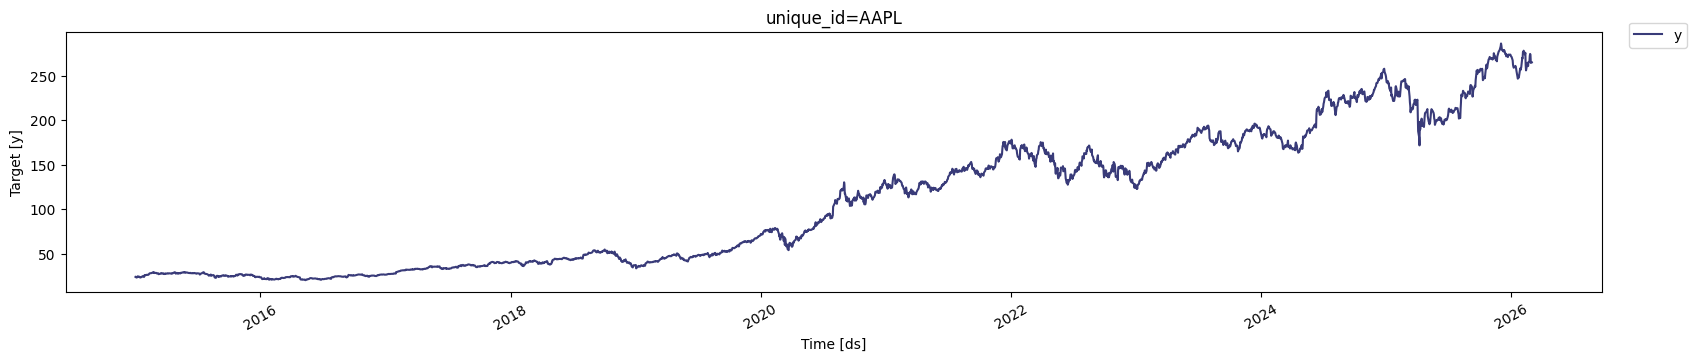

In [16]:
StatsForecast.plot(df)

In [17]:
#df['y'] = df['y'].diff()
df.dropna(inplace=True)

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

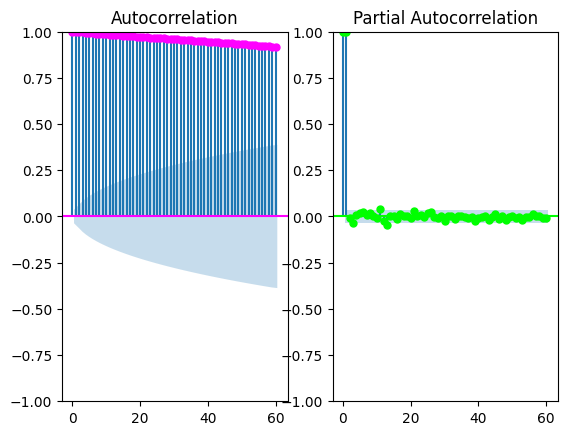

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=60, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

plot_pacf(df["y"],  lags=60, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

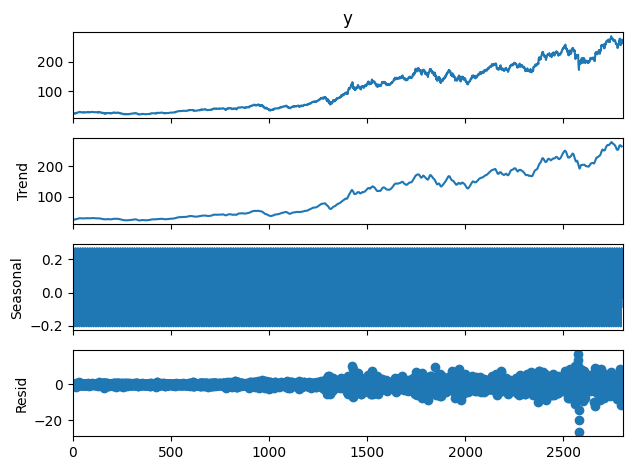

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose
a = seasonal_decompose(df["y"], model = "add", period=12)
a.plot();

In [21]:
from statsmodels.tsa.stattools import adfuller

In [24]:
def Augmented_Dickey_Fuller_Test_func(series ):
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
       dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [25]:
Augmented_Dickey_Fuller_Test_func(df['y'])

Test Statistic                    0.379385
p-value                           0.980707
No Lags Used                     10.000000
Number of observations used    2795.000000
Critical Value (1%)              -3.432692
Critical Value (5%)              -2.862575
Critical Value (10%)             -2.567321
dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


In [26]:
df['return'] = 100 * df["y"].pct_change()
df.dropna(inplace=True, how='any')
df.head()

,ds,y,unique_id,return
1,2015-01-05,23.532722,AAPL,-2.817162
2,2015-01-06,23.534935,AAPL,0.009402
3,2015-01-07,23.864944,AAPL,1.402211
4,2015-01-08,24.781897,AAPL,3.842255
5,2015-01-09,24.808466,AAPL,0.107213


In [35]:
import plotly.express as px
px.line(df, x=df["ds"], y="return",title="AAPL Return Chart")


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'ds=%{x}<br>return=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array(['2015-01-05T00:00:00.000000000', '2015-01-06T00:00:00.000000000',
                          '2015-01-07T00:00:00.000000000', ..., '2026-02-26T00:00:00.000000000',
                          '2026-02-27T00:00:00.000000000', '2026-03-02T00:00:00.000000000'],
                         shape=(2805,), dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('4V84HoyJBsAAHKJxTkGDPyTwGdx0b/' ... 'JHlmnf3b8W5ddlU7QJwKCwFrcVKso/'),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'AAPL Return Chart'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'ds'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'return'}}}
})

In [36]:
df['sq_return'] = df["return"].mul(df["return"])
df.head()

,ds,y,unique_id,return,sq_return
1,2015-01-05,23.532722,AAPL,-2.817162,7.936401
2,2015-01-06,23.534935,AAPL,0.009402,0.000088
3,2015-01-07,23.864944,AAPL,1.402211,1.966196
4,2015-01-08,24.781897,AAPL,3.842255,14.762927
5,2015-01-09,24.808466,AAPL,0.107213,0.011495


In [38]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2)

fig.add_trace(go.Scatter(x=df["ds"], y=df["return"],
                         mode='lines',
                         name='return'),
row=1, col=1
)


fig.add_trace(go.Scatter(x=df["ds"], y=df["sq_return"],
                         mode='lines',
                         name='sq_return'),
    row=1, col=2
)

fig.update_layout(height=600, width=800, title_text="Returns vs Squared Returns", template = "plotly_dark")
fig

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'mode': 'lines',
              'name': 'return',
              'type': 'scatter',
              'x': array(['2015-01-05T00:00:00.000000000', '2015-01-06T00:00:00.000000000',
                          '2015-01-07T00:00:00.000000000', ..., '2026-02-26T00:00:00.000000000',
                          '2026-02-27T00:00:00.000000000', '2026-03-02T00:00:00.000000000'],
                         shape=(2805,), dtype='datetime64[ns]'),
              'xaxis': 'x',
              'y': {'bdata': ('4V84HoyJBsAAHKJxTkGDPyTwGdx0b/' ... 'JHlmnf3b8W5ddlU7QJwKCwFrcVKso/'),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'mode': 'lines',
              'name': 'sq_return',
              'type': 'scatter',
              'x': array(['2015-01-05T00:00:00.000000000', '2015-01-06T00:00:00.000000000',
                          '2015-01-07T00:00:00.000000000', ..., '2026-02-26T00:00:00.000000000',
                          '2026-02-27T00:00:00.000000000', '2026-03-02T00:00:00.000000000'],
                         shape=(2805,), dtype='datetime64[ns]'),
              'xaxis': 'x2',
              'y': {'bdata': ('KJ5rx9++H0C33rzcJCwXP5O/CsaJdf' ... 'BcKQfjyz9YbDR6uqUkQPk2lKKaZKU/'),
                    'dtype': 'f8'},
              'yaxis': 'y2'}],
    'layout': {'height': 600,
               'template': '...',
               'title': {'text': 'Returns vs Squared Returns'},
               'width': 800,
               'xaxis': {'anchor': 'y', 'domain': [0.0, 0.45]},
               'xaxis2': {'anchor': 'y2', 'domain': [0.55, 1.0]},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0]},
               'yaxis2': {'anchor': 'x2', 'domain': [0.0, 1.0]}}
})

In [39]:
from scipy.stats import probplot, moment
from statsmodels.tsa.stattools import adfuller, q_stat, acf
import numpy as np
import seaborn as sns

def plot_correlogram(x, lags=None, title=None):
    lags = min(10, int(len(x)/5)) if lags is None else lags
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
    x.plot(ax=axes[0][0], title='Return')
    x.rolling(21).mean().plot(ax=axes[0][0], c='k', lw=1)
    q_p = np.max(q_stat(acf(x, nlags=lags), len(x))[1])
    stats = f'Q-Stat: {np.max(q_p):>8.2f}\nADF: {adfuller(x)[1]:>11.2f}'
    axes[0][0].text(x=.02, y=.85, s=stats, transform=axes[0][0].transAxes)
    probplot(x, plot=axes[0][1])
    mean, var, skew, kurtosis = moment(x, moment=[1, 2, 3, 4])
    s = f'Mean: {mean:>12.2f}\nSD: {np.sqrt(var):>16.2f}\nSkew: {skew:12.2f}\nKurtosis:{kurtosis:9.2f}'
    axes[0][1].text(x=.02, y=.75, s=s, transform=axes[0][1].transAxes)
    plot_acf(x=x, lags=lags, zero=False, ax=axes[1][0])
    plot_pacf(x, lags=lags, zero=False, ax=axes[1][1])
    axes[1][0].set_xlabel('Lag')
    axes[1][1].set_xlabel('Lag')
    fig.suptitle(title+ f'Dickey-Fuller: {adfuller(x)[1]:>11.2f}', fontsize=14)
    sns.despine()
    fig.tight_layout()
    fig.subplots_adjust(top=.9)

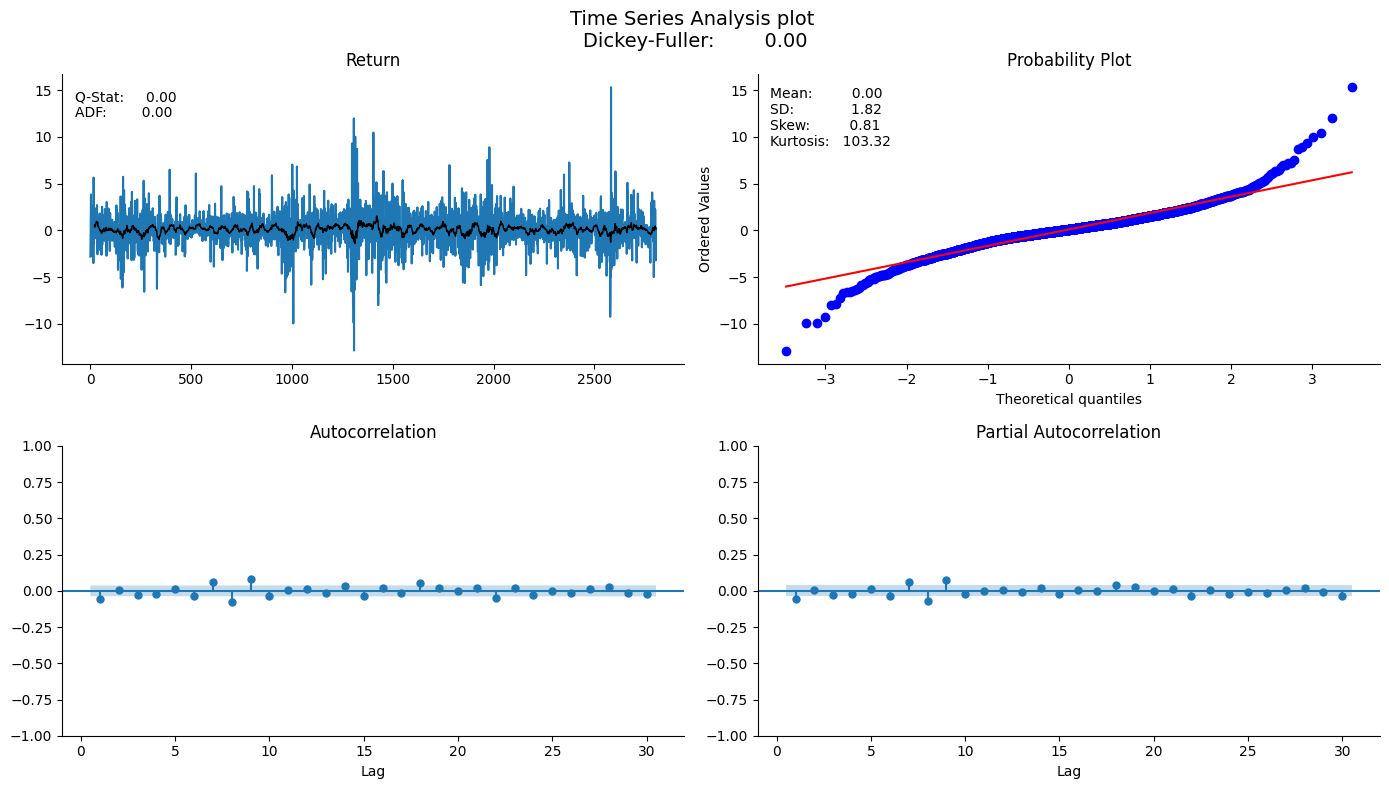

In [40]:
plot_correlogram(df["return"], lags=30, title="Time Series Analysis plot \n")

Ljung-Box test statistic, Ljung-Box p-values, Box-Pierce test statistic, and Box-Pierce p-values

In [41]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_res = acorr_ljungbox(df["return"], lags= 40, boxpierce=True)

ljung_res.head()

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,7.901125,0.004940,7.892681,0.004964
2,8.004014,0.018279,7.995423,0.018358
3,10.438802,0.015182,10.425874,0.015272
4,11.712614,0.019621,11.696964,0.019753
5,12.270489,0.031264,12.253447,0.031475


In [42]:
df=df[["ds","unique_id","return"]]
df.columns=["ds", "unique_id", "y"]

In [44]:
train = df[df.ds<='2026-01-01'] # Let's forecast the last 30 days
test = df[df.ds>'2026-01-01']

In [45]:
train.shape, test.shape

((2765, 3), (40, 3))

# CV

In [46]:
from statsforecast import StatsForecast
from statsforecast.models import GARCH

In [47]:
season_length = 7 # Dayly data
horizon = len(test) # number of predictions biasadj=True, include_drift=True,

models = [GARCH(1,1),
          GARCH(1,2),
          GARCH(2,2),
          GARCH(2,1),
          GARCH(3,1),
          GARCH(3,2),
          GARCH(3,3),
          GARCH(1,3),
          GARCH(2,3)]

In [48]:
sf = StatsForecast(
    models=models,
    freq='C', # custom business day frequency
)

In [49]:
crossvalidation_df = sf.cross_validation(df=train,
                                         h=horizon,
                                         step_size=6,
                                         n_windows=5)

In [50]:
crossvalidation_df

,unique_id,ds,cutoff,y,"GARCH(1,1)","GARCH(1,2)","GARCH(2,2)","GARCH(2,1)","GARCH(3,1)","GARCH(3,2)","GARCH(3,3)","GARCH(1,3)","GARCH(2,3)"
0,AAPL,2025-10-01,2025-09-30,0.322034,2.680142,2.654915,2.664331,2.666684,2.695325,2.672834,2.635006,2.658999,2.675278
1,AAPL,2025-10-02,2025-09-30,0.657663,-1.092031,-1.125769,-1.108601,-1.063132,-1.072878,-1.101096,-1.085444,-1.140150,-1.122077
2,AAPL,2025-10-03,2025-09-30,0.346128,-0.913075,-0.892999,-0.902485,-0.919372,-0.874658,-0.864165,-0.918387,-0.911747,-0.907496
3,AAPL,2025-10-06,2025-09-30,-0.515458,-1.790415,-1.789241,-1.790506,-1.790078,-1.814278,-1.846145,-1.786207,-1.736029,-1.759692
4,AAPL,2025-10-07,2025-09-30,-0.081814,1.459792,1.471499,1.463751,1.443001,1.458548,1.455723,1.444987,1.481396,1.489060
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,AAPL,2025-12-24,2025-11-03,0.532382,-0.034786,-0.017302,-0.017222,-0.017052,-0.016780,-0.016936,-0.017206,-0.017516,-0.017345
196,AAPL,2025-12-26,2025-11-03,-0.149735,-3.043417,-1.468352,-1.465484,-1.462271,-1.450180,-1.455029,-1.470677,-1.473147,-1.473956
197,AAPL,2025-12-29,2025-11-03,0.131681,0.652702,0.325584,0.321766,0.313870,0.314709,0.320031,0.314552,0.328508,0.326250
198,AAPL,2025-12-30,2025-11-03,-0.248399,4.526531,2.166343,2.171372,2.197441,2.138742,2.116717,2.189482,2.211010,2.187512


In [52]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse

In [53]:
evals = evaluate(crossvalidation_df.drop(columns='cutoff'), metrics=[rmse], agg_fn='mean')
evals

,metric,"GARCH(1,1)","GARCH(1,2)","GARCH(2,2)","GARCH(2,1)","GARCH(3,1)","GARCH(3,2)","GARCH(3,3)","GARCH(1,3)","GARCH(2,3)"
0,rmse,2.201392,1.9785,1.970505,1.963242,1.982078,1.990262,1.957747,1.98332,1.97211


In [54]:
evals.drop(columns='metric').loc[0].idxmin()

'GARCH(3,3)'

# FIT

In [55]:
season_length = 7 # Dayly data
horizon = len(test) # number of predictions biasadj=True, include_drift=True,

models = [GARCH(3,3)]

In [56]:
sf = StatsForecast(models=models,
                   freq='C', # custom business day frequency
                  )

In [57]:
sf.fit(df=train)

StatsForecast(models=[GARCH(3,3)])

In [58]:
result=sf.fitted_[0,0].model_
result

{'p': 3,
 'q': 3,
 'coeff': array([4.00446495e-01, 9.17847838e-02, 9.08963461e-02, 8.23774614e-02,
        1.15384859e-16, 0.00000000e+00, 6.08076280e-01]),
 'message': 'Optimization terminated successfully',
 'y_vals': array([ 0.13168132, -0.24839933, -0.44676015]),
 'sigma2_vals': array([1.32548691, 1.2808828 , 1.25650535]),
 'fitted': array([        nan,         nan,         nan, ..., -0.23933163,
         0.94255171,  0.69137369], shape=(2765,)),
 'actual_residuals': array([        nan,         nan,         nan, ...,  0.37101295,
        -1.19095104, -1.13813384], shape=(2765,))}

In [59]:
residual=pd.DataFrame(result.get("actual_residuals"), columns=["residual Model"])
residual

,residual Model
0,NaN
1,NaN
2,NaN
3,0.917627
4,0.958013
...,...
2760,1.964815
2761,1.698192
2762,0.371013
2763,-1.190951


/tmp/ipykernel_3726/2216367516.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, ax=axs[0,1]);


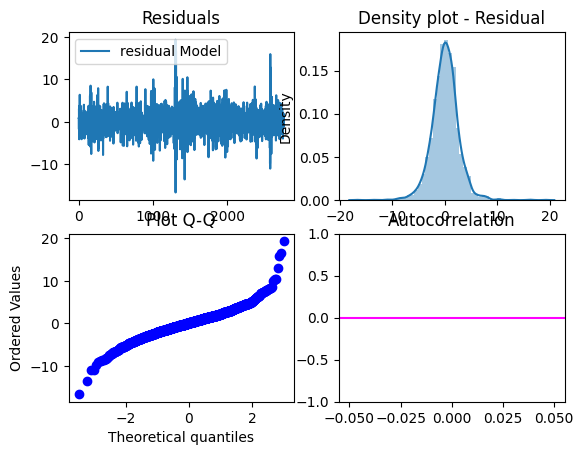

In [60]:
from scipy import stats

fig, axs = plt.subplots(nrows=2, ncols=2)

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals");

# plot
sns.distplot(residual, ax=axs[0,1]);
axs[0,1].set_title("Density plot - Residual");

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation");

plt.show()

In [61]:
Y_hat = sf.forecast(df=train, h=horizon, fitted=True)
Y_hat.head()

,unique_id,ds,"GARCH(3,3)"
0,AAPL,2026-01-01,1.802804
1,AAPL,2026-01-02,-0.749459
2,AAPL,2026-01-05,-0.652867
3,AAPL,2026-01-06,-1.317345
4,AAPL,2026-01-07,1.079985


In [62]:
values=sf.forecast_fitted_values()
values.head()

,unique_id,ds,y,"GARCH(3,3)"
0,AAPL,2015-01-05,-2.817162,NaN
1,AAPL,2015-01-06,0.009402,NaN
2,AAPL,2015-01-07,1.402211,NaN
3,AAPL,2015-01-08,3.842255,2.924628
4,AAPL,2015-01-09,0.107213,-0.850800


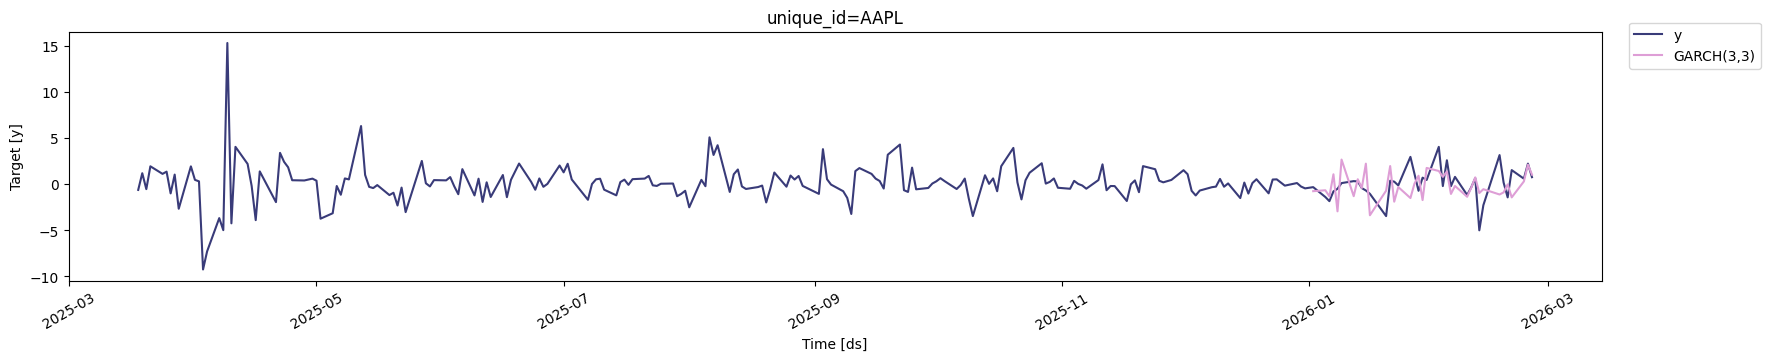

In [63]:
sf.plot(train, Y_hat.merge(test), max_insample_length=200)

# CI

In [64]:
forecast_df = sf.predict(h=horizon, level=[80,95])
forecast_df.head(10)

,unique_id,ds,"GARCH(3,3)","GARCH(3,3)-lo-95","GARCH(3,3)-lo-80","GARCH(3,3)-hi-80","GARCH(3,3)-hi-95"
0,AAPL,2026-01-01,1.802804,-0.611480,0.224188,3.381420,4.217088
1,AAPL,2026-01-02,-0.749459,-3.691083,-2.672884,1.173965,2.192165
2,AAPL,2026-01-05,-0.652867,-3.647529,-2.610971,1.305237,2.341794
3,AAPL,2026-01-06,-1.317345,-4.271771,-3.249140,0.614450,1.637081
4,AAPL,2026-01-07,1.079985,-1.972421,-0.915876,3.075846,4.132391
5,AAPL,2026-01-08,-2.937907,-6.131560,-5.026125,-0.849690,0.255746
6,AAPL,2026-01-09,2.679438,-1.942650,-0.342783,5.701658,7.301525
7,AAPL,2026-01-12,-1.293390,-6.951896,-4.993288,2.406508,4.365116
8,AAPL,2026-01-13,0.544092,-5.156307,-3.183199,4.271383,6.244492
9,AAPL,2026-01-14,-0.402491,-5.508376,-3.741050,2.936067,4.703394


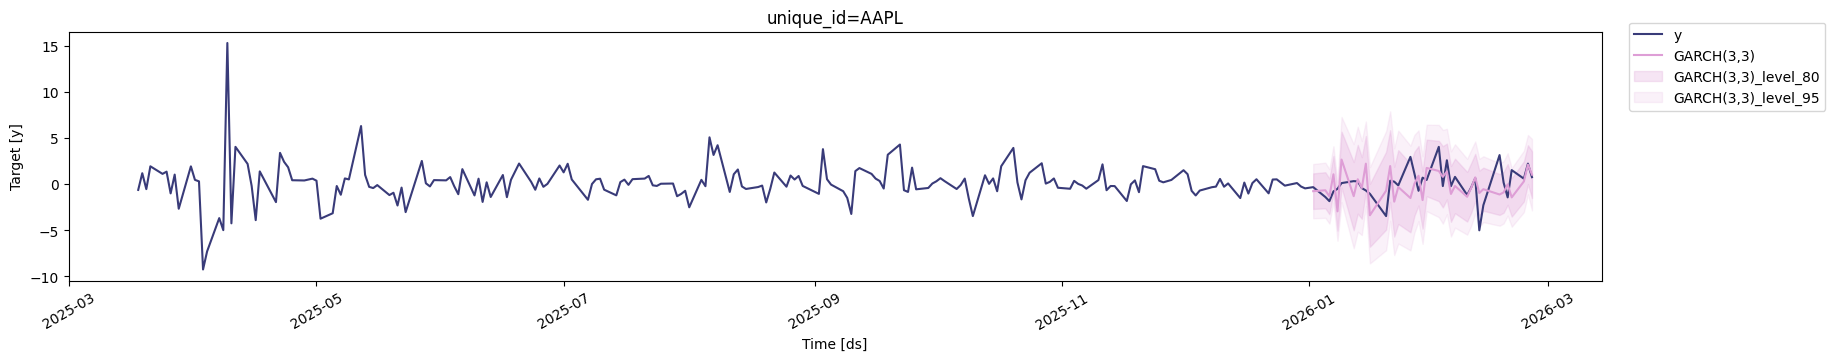

In [65]:
sf.plot(train, test.merge(forecast_df), level=[80, 95], max_insample_length=200)